In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
%matplotlib inline

In [2]:
secretNumber = '110011110011100000'

In [3]:
circuit = QuantumCircuit(len(secretNumber)+1,len(secretNumber))

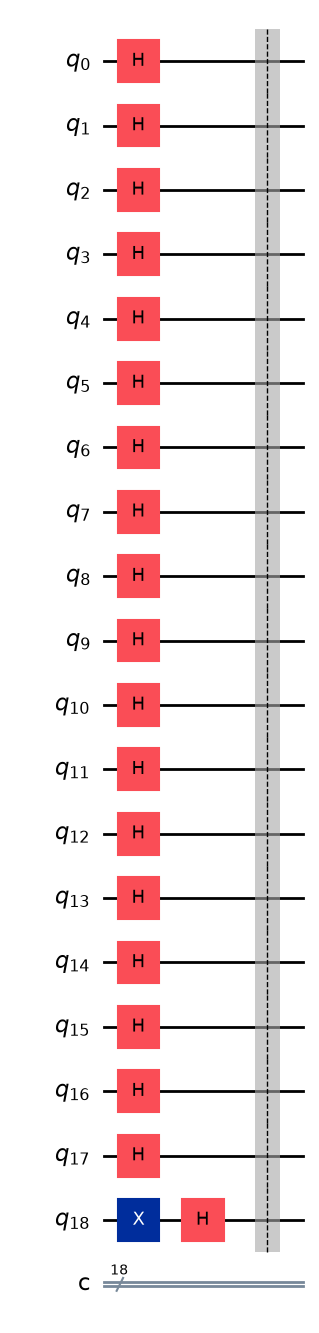

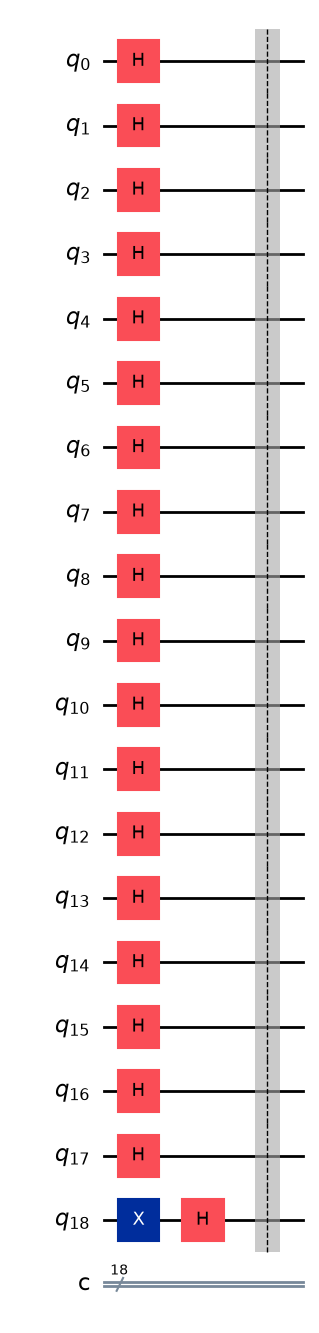

In [4]:
circuit.h(range(len(secretNumber)))
circuit.x(len(secretNumber))
circuit.h(len(secretNumber))

circuit.barrier()

circuit.draw(output="mpl")

index 0 is 0
index 1 is 0
index 2 is 0
index 3 is 0
index 4 is 0
index 5 is 1
index 6 is 1
index 7 is 1
index 8 is 0
index 9 is 0
index 10 is 1
index 11 is 1
index 12 is 1
index 13 is 1
index 14 is 0
index 15 is 0
index 16 is 1
index 17 is 1


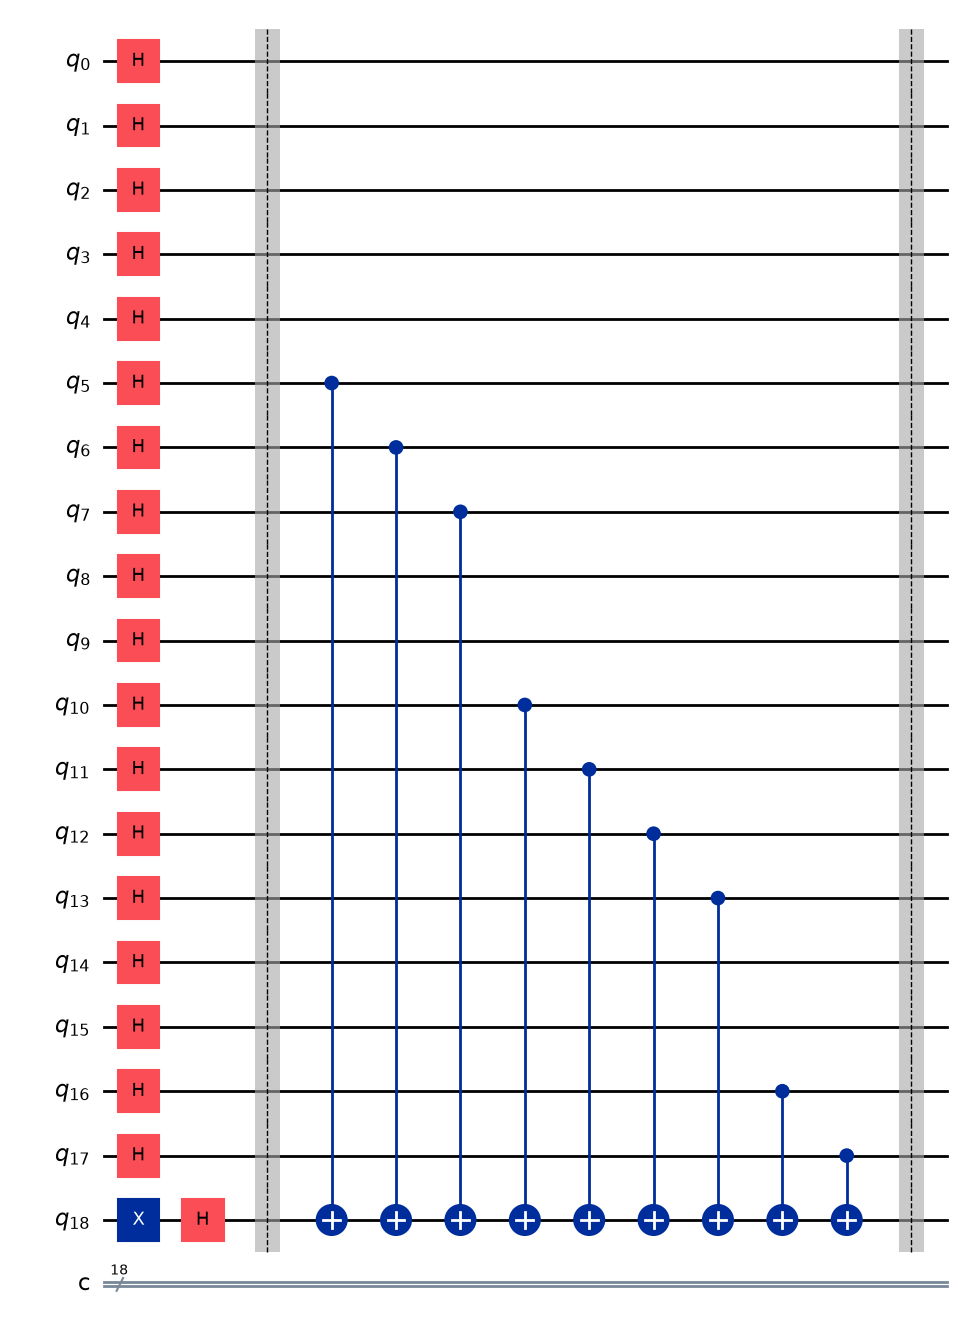

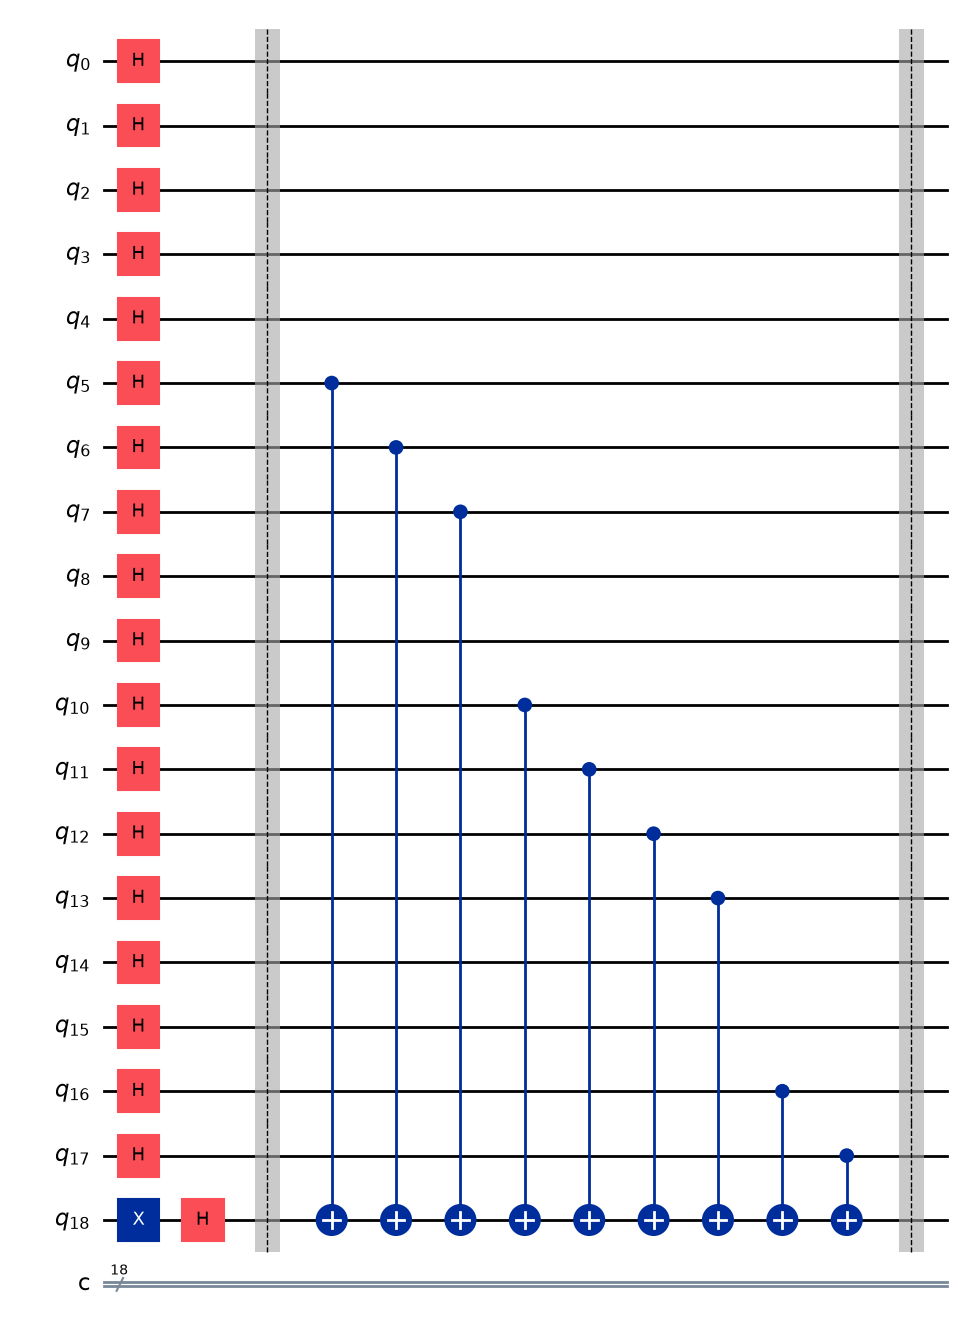

In [5]:
for index, one in enumerate(secretNumber[::-1]):
    print(f"index {index} is {one}")
    if one == "1":
        circuit.cx(index, len(secretNumber))

circuit.barrier()

circuit.draw(output="mpl")

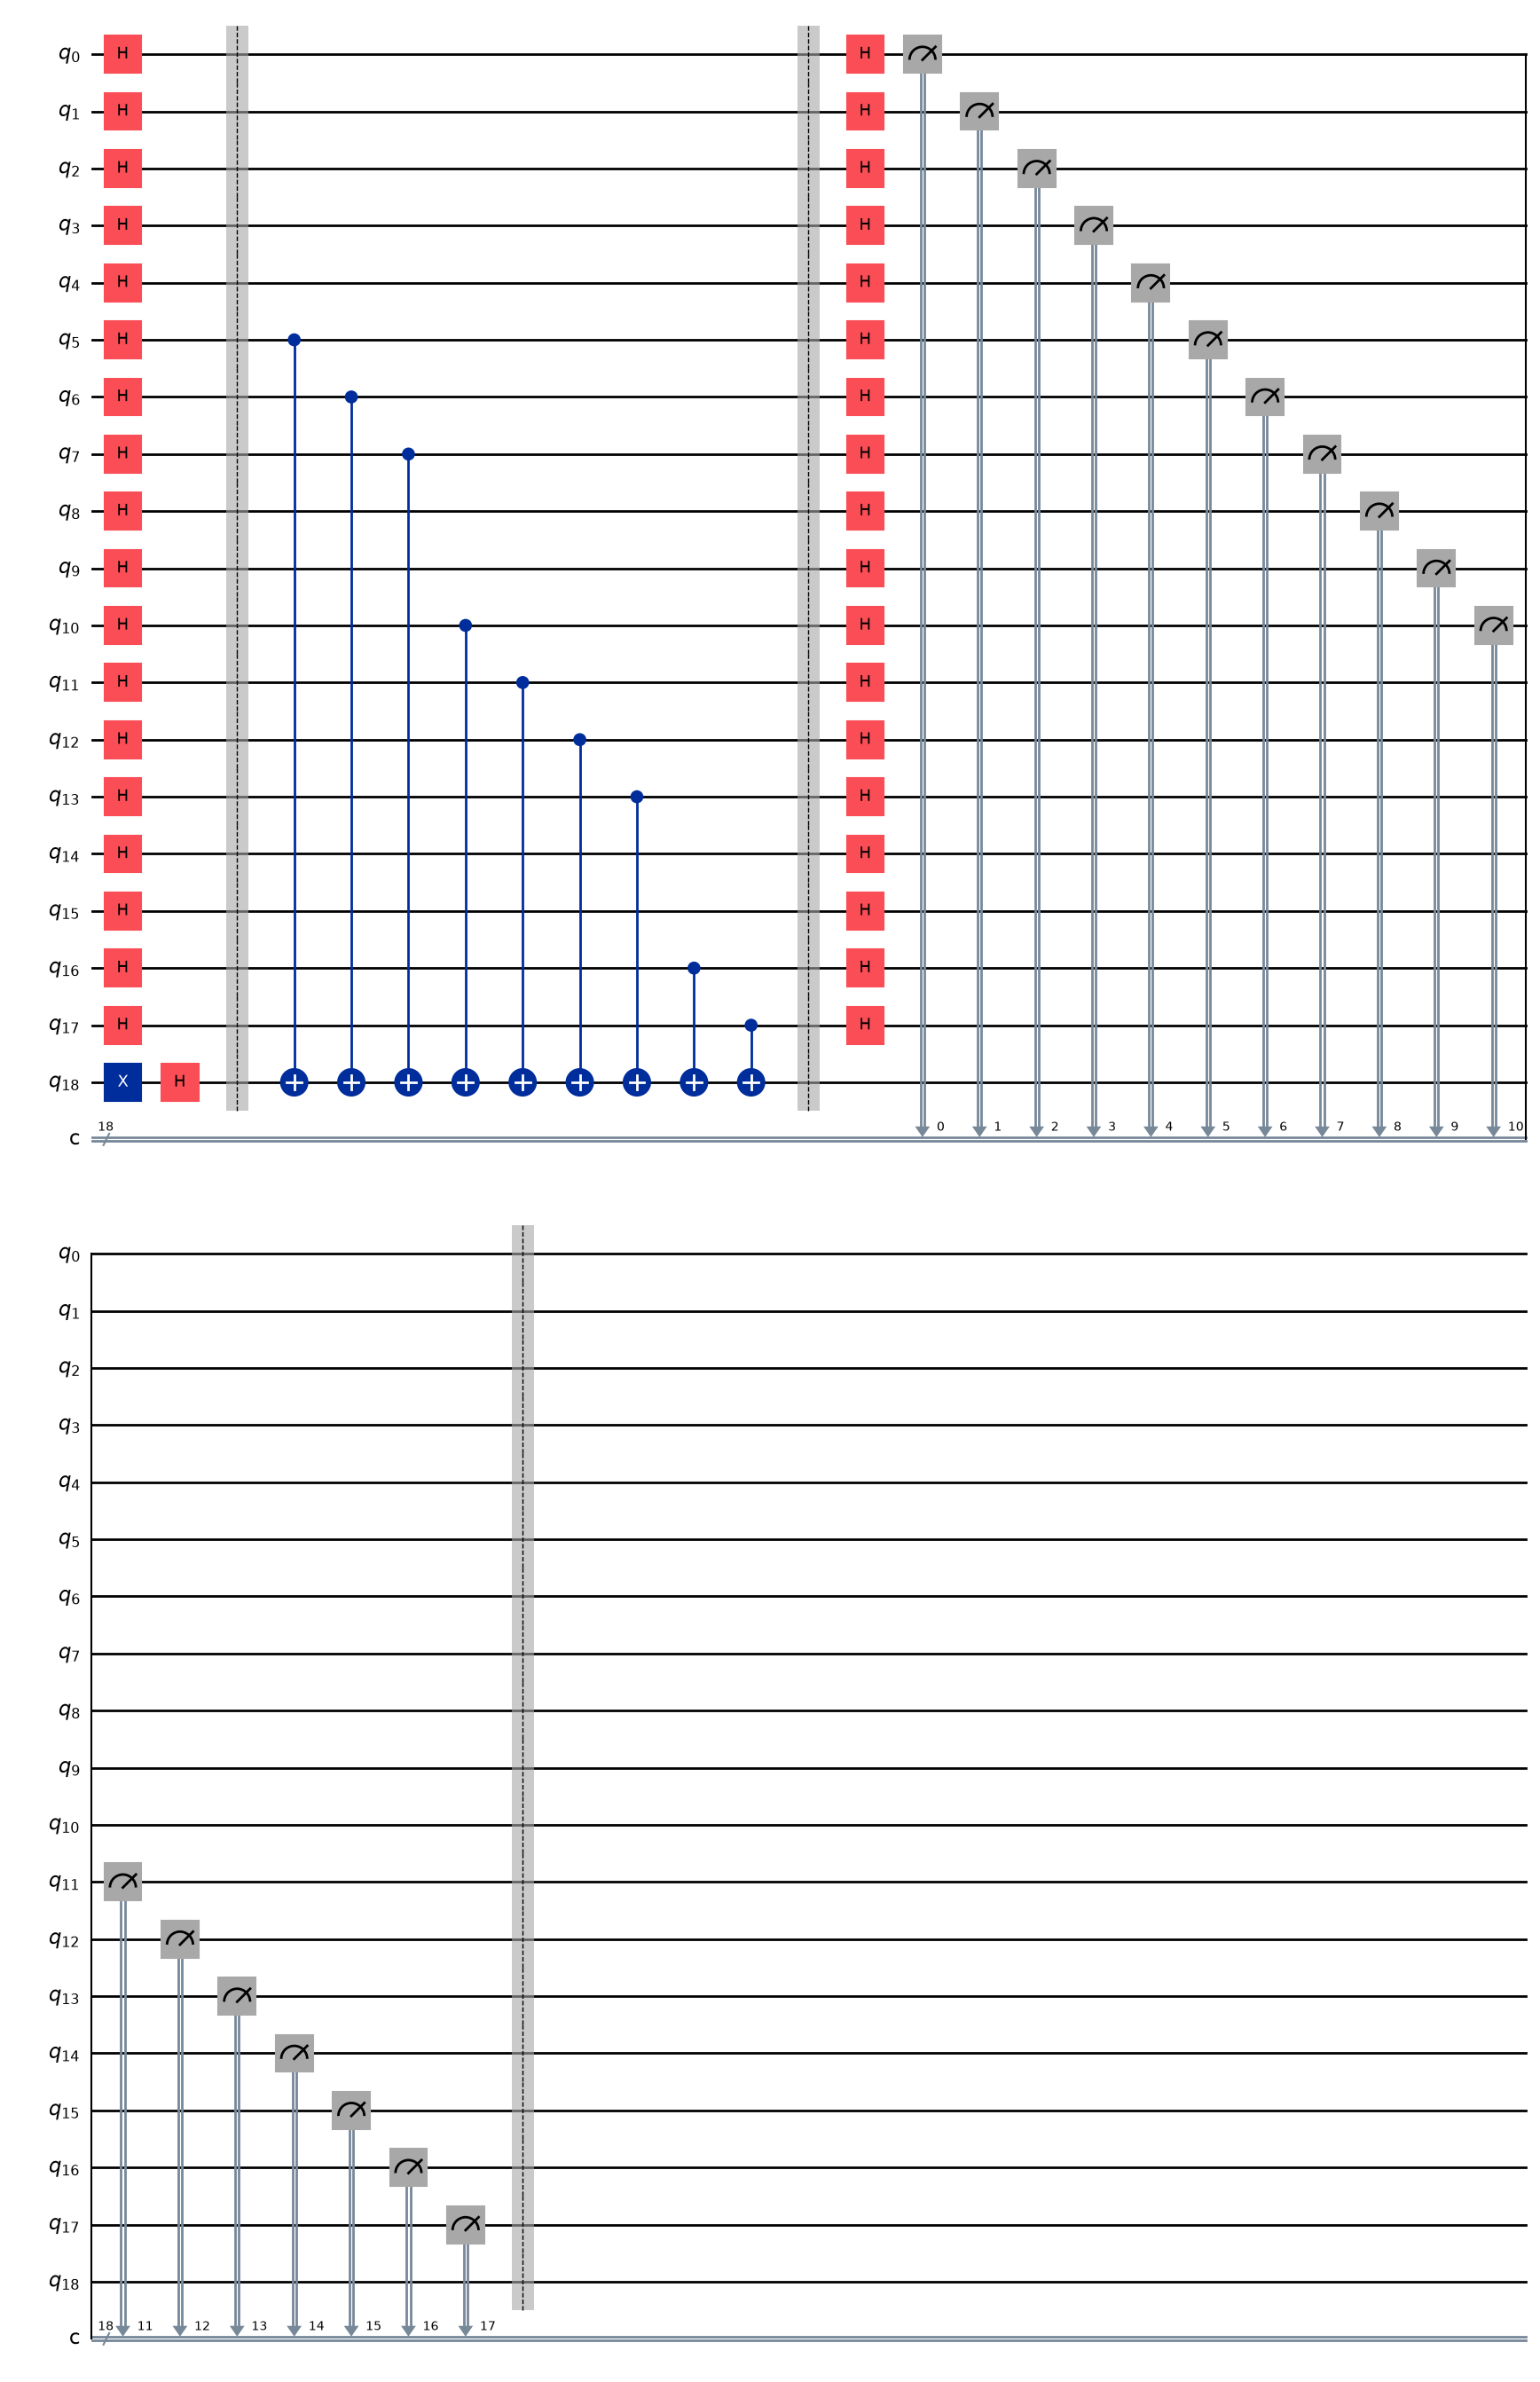

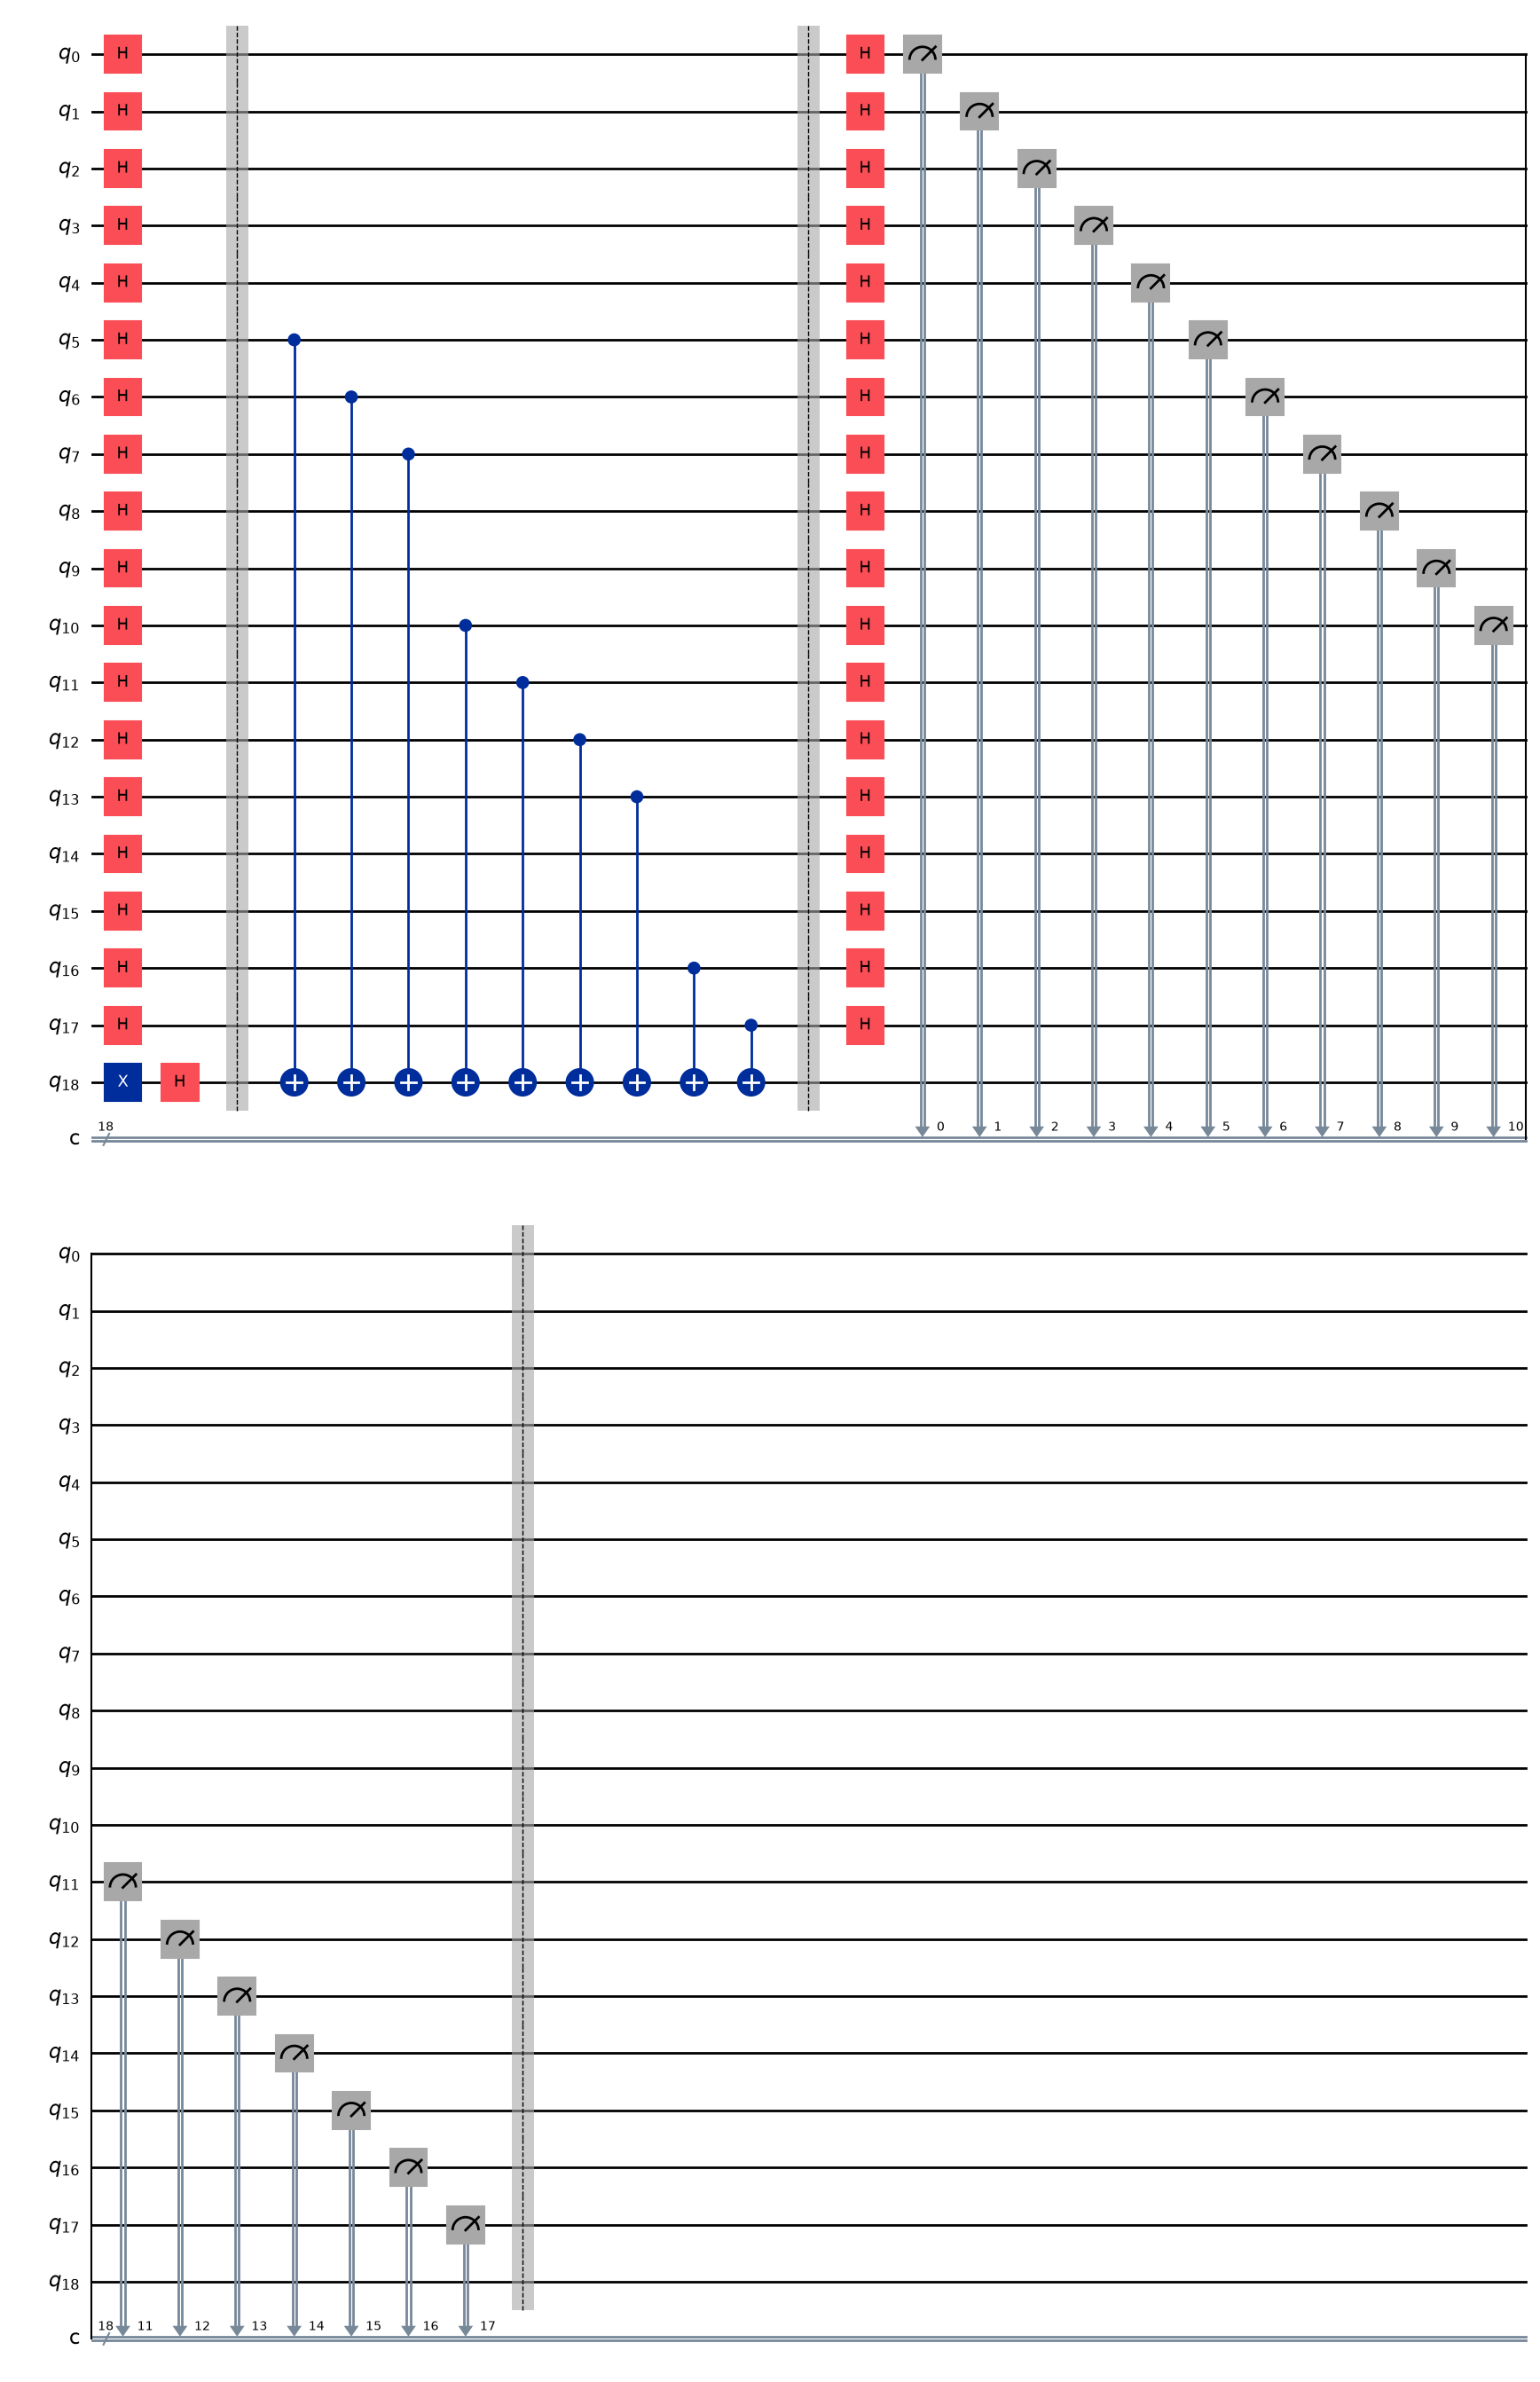

In [6]:
circuit.h(range(len(secretNumber)))
circuit.measure(range(len(secretNumber)),range(len(secretNumber)))

circuit.barrier()

circuit.draw(output="mpl")

In [7]:
simulator = AerSimulator()
compiled = transpile(circuit, simulator)
result = simulator.run(compiled, shots = 1024).result()
counts = result.get_counts()
print(counts)

{'110011110011100000': 1024}
